In [1]:
import os
from pyhere import here

project_dir = here(".")
os.chdir(project_dir)

print(os.getcwd())


/Users/work/Data Science/sheffield-bats


In [2]:
%load_ext autoreload
%autoreload 2

import json

import elapid as ela
import geopandas as gpd
import rioxarray as rxr

from sklearn.metrics import roc_auc_score
from folium import Map, GeoJson, CircleMarker
from matplotlib import pyplot as plt


from sdm.models.utils.utils import prepare_occurrence_data
from sdm.models.maxent.maxent_model import evaluate_and_train_maxent_model
from sdm.raster.io import load_environmental_variables
from sdm.raster.utils import generate_point_grid
from sdm.occurrence.species_data import latin_name, activity_type, genus
from sdm.utils.io import load_config
from sdm.utils.io import load_boundary

from pathlib import Path

In [3]:
# load the config
config = load_config()
config


{'paths': {'raw_data': 'data/raw',
  'processed_data': 'data/processed',
  'models': 'data/sdm_models',
  'tuning_dir': 'data/sdm_tuning',
  'predictions': 'data/sdm_predictions',
  'model_config': 'model_config.yml',
  'variables_config': 'variables_config.yml',
  'occurence_data': 'data/processed/bats-tidy.geojson',
  'background_points': 'data/processed/background-points.geojson',
  'boundary': 'data/processed/boundary.geojson',
  'grid_points': 'data/evs/grid-points.parquet',
  'evs': 'data/processed/evs',
  'ev_tiff': 'data/evs/evs-to-model.tif'},
 'spatial': {'top': 646900,
  'left': 313000,
  'crs': 'EPSG:27700',
  'resolution': 100,
  'study_area_buffer': 7000},
 'crs': 'EPSG:27700',
 'mlflow': {'tracking_uri': 'sqlite:///mlflow.db',
  'experiment_name': 'species_sdm_experiment'}}

In [4]:
import topojson as tp

boundary = load_boundary(
    filepath=config["paths"]["boundary"], buffer_distance=0, target_crs=27700
)

# simplify the boundary to regions to make the calculation faster
boundary_tp = tp.Topology(boundary, prequantize=True)
boundary_tp.toposimplify(100, inplace=True)
boundary = boundary_tp.to_gdf()
boundary["geometry"] = boundary.geometry.make_valid()
boundary["geometry"] = boundary.geometry.buffer(0)


boundary_4326 = boundary.to_crs(4326)
boundary_4326

,geometry,County
0,"MULTIPOLYGON (((-0.92927 53.77354, -0.93328 53...",East Riding of Yorkshire
1,"MULTIPOLYGON (((-0.78862 54.56019, -0.78826 54...",North Yorkshire
2,"POLYGON ((-1.82224 53.52109, -1.80427 53.537, ...",South Yorkshire
3,"POLYGON ((-1.82224 53.52109, -1.82714 53.52349...",West Yorkshire


# Environmental Variables

In [5]:
evs_to_model, ev_path = load_environmental_variables(config["paths"]["ev_tiff"])

all_env_var_names = list(evs_to_model.data_vars.keys())
evs_to_model

<xarray.Dataset> Size: 596MB
Dimensions:                                  (x: 1930, y: 1544)
Coordinates:
  * x                                        (x) float64 15kB 3.562e+05 ... 5...
  * y                                        (y) float64 12kB 3.716e+05 ... 5...
    spatial_ref                              int64 8B 0
Data variables: (12/50)
    climate_stats_temp_ann_var               (y, x) float32 12MB ...
    climate_bioclim_bio_4                    (y, x) float32 12MB ...
    climate_bioclim_bio_7                    (y, x) float32 12MB ...
    climate_bioclim_bio_2                    (y, x) float32 12MB ...
    climate_stats_prec_ann_var               (y, x) float32 12MB ...
    terrain_dtm                              (y, x) float32 12MB ...
    ...                                       ...
    vom_vegetation_height_mean_500m          (y, x) float32 12MB ...
    ceh_landcover_suburban_500m              (y, x) float32 12MB ...
    os_cover_water_500m                      (y, x) float32 12MB ...
    ceh_landcover_coniferous_woodland_500m   (y, x) float32 12MB ...
    ceh_landcover_urban_500m                 (y, x) float32 12MB ...
    ceh_landcover_improved_grassland_500m    (y, x) float32 12MB ...
Attributes:
    AREA_OR_POINT:  Area

In [6]:
## Convert the env vars to a dataframe to make it easy to join with occurence

ev_df = evs_to_model.to_dataframe()
ev_df.reset_index(inplace=True)
ev_gdf = gpd.GeoDataFrame(ev_df, geometry=gpd.points_from_xy(ev_df.x, ev_df.y))
ev_gdf.crs = evs_to_model.rio.crs
ev_gdf = ev_gdf.drop(columns=["spatial_ref"])
ev_gdf.rename(columns={"x": "grid_x", "y": "grid_y"}, inplace=True)

# Drop rows with missing values - can't be used for modelling
# TODO: interpolate missing values
ev_gdf.dropna(inplace=True)

ev_gdf.head()


,grid_x,grid_y,climate_stats_temp_ann_var,climate_bioclim_bio_4,climate_bioclim_bio_7,climate_bioclim_bio_2,climate_stats_prec_ann_var,terrain_dtm,climate_stats_prec_ann_avg,climate_stats_temp_ann_avg,...,ceh_landcover_arable_500m,vom_vegetation_height_max_500m,ceh_landcover_broadleaved_woodland_500m,vom_vegetation_height_mean_500m,ceh_landcover_suburban_500m,os_cover_water_500m,ceh_landcover_coniferous_woodland_500m,ceh_landcover_urban_500m,ceh_landcover_improved_grassland_500m,geometry
8703,356750.0,469950.0,4.159956,434.165009,17.891073,6.514693,27.460451,59.227085,111.416664,8.851787,...,35.0,10.457754,762.0,0.960688,335.0,1.16,5.0,22.0,8718.0,POINT (356750 469950)
8704,356750.0,470050.0,4.159015,434.076752,17.890902,6.510063,27.317068,71.512306,111.666664,8.850486,...,35.0,10.673230,824.0,1.024941,335.0,1.31,5.0,14.0,8664.0,POINT (356750 470050)
8705,356750.0,470150.0,4.158071,433.988586,17.890728,6.505465,27.206387,81.863503,111.750000,8.849172,...,40.0,11.073326,936.0,1.124981,335.0,1.56,5.0,14.0,8547.0,POINT (356750 470150)
8706,356750.0,470250.0,4.157125,433.900543,17.890556,6.500897,27.492424,89.127396,112.000000,8.847846,...,50.0,11.196786,1040.0,1.201037,339.0,1.84,5.0,14.0,8429.0,POINT (356750 470250)
8707,356750.0,470350.0,4.156174,433.812592,17.890383,6.496360,27.444262,87.964066,112.250000,8.846507,...,95.0,10.799233,1045.0,1.181763,339.0,1.95,5.0,14.0,8406.0,POINT (356750 470350)


# Load the Occurence

In [7]:
# load the occurrence data
bat_records = gpd.read_file(config["paths"]["occurence_data"])
bat_records = bat_records[bat_records.accuracy <= 100]


from leafmap.deckgl import Map

map_center = boundary_4326.union_all().centroid
m = Map(center=(map_center.y, map_center.x), zoom=7)

m.add_gdf(
    boundary,
    zoom_to_layer=False,
    get_fill_color=[60, 60, 60, 40],
)

m.add_gdf(
    bat_records,
    zoom_to_layer=False,
    get_radius=500,
    # pink
    get_fill_color=[255, 192, 203, 180],
)

m


Map(custom_attribution='', layers=(SolidPolygonLayer(get_fill_color=[60, 60, 60, 40], table=arro3.core.Table
+…

# Pick Species


In [8]:
latin_name = "Pipistrellus pygmaeus"
activity_type = "In flight"

# Generate Data

<Axes: >

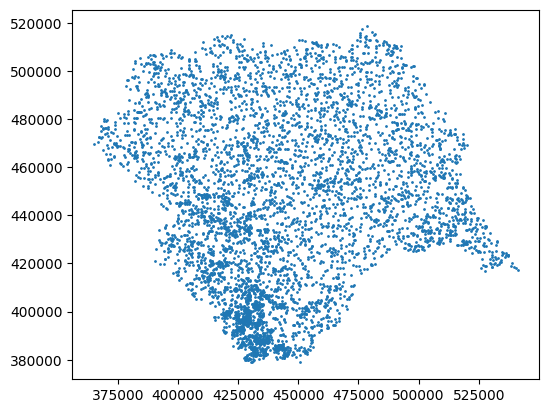

In [9]:
from sdm.occurrence.sampling import (
    generate_background_points_from_data,
    BackgroundMethod,
    TransformMethod,
)


# genrate the background points
background_points, density_array = generate_background_points_from_data(
    occurrence_data=bat_records,  # [bat_records.activity_type == activity_type],
    boundary=boundary,
    n_background_points=8000,
    background_method=BackgroundMethod.CONTRAST,
    background_value=0.025,
    sigma=6.5,
    transform_method=TransformMethod.PRESENCE,
    # region_weighting_factor=0.5,
    clip_to_boundary=True,
)

background_points.rename(columns={"presence": "class"}, inplace=True)

background_points.plot(
    markersize=1,
)

In [10]:
# use leafmap foliumap to plot the map
from leafmap.foliumap import Map
from folium import GeoJson, CircleMarker


centroid = boundary_4326.union_all().centroid
m = Map(location=[centroid.y, centroid.x], zoom_start=8, tiles="CartoDB positron")

# Add boundary
GeoJson(
    boundary, style_function=lambda x: {"fillColor": "none", "color": "black"}
).add_to(m)


# Add background points
GeoJson(
    background_points,
    style_function=lambda x: {
        "fillColor": "green",
        "color": "green",
        "radius": 3,
        "fillOpacity": 1,
        "weight": 0.5,
    },
    marker=CircleMarker(radius=3),
).add_to(m)

# Add bats points
GeoJson(
    bat_records[["geometry"]],
    style_function=lambda x: {
        "color": "orange",
        "fillColor": "orange",
        "radius": 3,
        "weight": 0.5,
        "fillOpacity": 1,
    },
    marker=CircleMarker(radius=3),
).add_to(m)

m


## Prepare Training Data

In [11]:
split_keys = ["latin_name", "activity_type"]

bat_records = bat_records[split_keys + ["geometry"]]
bat_records["class"] = 1
bat_records[split_keys].value_counts().to_frame()


count
latin_name                activity_type       
Pipistrellus pipistrellus Roost           4075
                          In flight       3258
Plecotus auritus          Roost           1548
Pipistrellus pygmaeus     Roost           1067
Myotis nattereri          Roost            707
Pipistrellus pygmaeus     In flight        602
Nyctalus noctula          In flight        559
Myotis daubentonii        In flight        441
                          Roost            424
Nyctalus noctula          Roost            273
Myotis mystacinus         Roost            249
Plecotus auritus          In flight        225
Nyctalus leisleri         In flight        172
Myotis nattereri          In flight         72
Nyctalus leisleri         Roost             50
Myotis brandtii           Roost             47
Myotis mystacinus         In flight         39
Pipistrellus nathusii     Roost             32
                          In flight         15
Myotis brandtii           In flight         13
Eptesicus serotinus       In flight          4
Vespertilio murinus       In flight          1

In [12]:
## Annotate the points with the environmental variables
resolution = evs_to_model.rio.resolution()
tolerance = abs(resolution[0])

occurence_data = gpd.sjoin_nearest(
    bat_records, ev_gdf, how="inner", max_distance=tolerance
)
background_data = gpd.sjoin_nearest(
    background_points, ev_gdf, how="inner", max_distance=tolerance
)

occurence_data.drop(columns=["index_right"], inplace=True)
background_data.drop(columns=["index_right"], inplace=True)

occurence_data.head()


,latin_name,activity_type,geometry,class,grid_x,grid_y,climate_stats_temp_ann_var,climate_bioclim_bio_4,climate_bioclim_bio_7,climate_bioclim_bio_2,...,ceh_landcover_grassland_500m,ceh_landcover_arable_500m,vom_vegetation_height_max_500m,ceh_landcover_broadleaved_woodland_500m,vom_vegetation_height_mean_500m,ceh_landcover_suburban_500m,os_cover_water_500m,ceh_landcover_coniferous_woodland_500m,ceh_landcover_urban_500m,ceh_landcover_improved_grassland_500m
0,Nyctalus noctula,In flight,POINT (465350 457750),1,465350.0,457750.0,4.370765,457.289093,19.998690,7.670608,...,0.0,1236.0,10.552817,1450.0,2.058665,139.0,2.73,391.0,20.0,6621.0
1,Nyctalus noctula,In flight,POINT (429550 477250),1,429550.0,477250.0,4.276229,447.886993,19.274574,7.206034,...,2.0,2161.0,11.823381,2267.0,1.776723,49.0,25.67,73.0,140.0,2726.0
2,Nyctalus noctula,In flight,POINT (446450 435450),1,446450.0,435450.0,4.431757,461.542175,20.190638,7.692239,...,0.0,8152.0,4.328964,312.0,0.395401,129.0,0.99,0.0,122.0,1210.0
3,Nyctalus noctula,In flight,POINT (439650 467050),1,439650.0,467050.0,4.357553,455.122711,19.600000,7.385443,...,0.0,1258.0,12.764629,339.0,1.336935,4514.0,5.96,0.0,1527.0,2002.0
4,Nyctalus noctula,In flight,POINT (429550 477250),1,429550.0,477250.0,4.276229,447.886993,19.274574,7.206034,...,2.0,2161.0,11.823381,2267.0,1.776723,49.0,25.67,73.0,140.0,2726.0


In [13]:
background_data.head()

,geometry,class,density,grid_x,grid_y,climate_stats_temp_ann_var,climate_bioclim_bio_4,climate_bioclim_bio_7,climate_bioclim_bio_2,climate_stats_prec_ann_var,...,ceh_landcover_grassland_500m,ceh_landcover_arable_500m,vom_vegetation_height_max_500m,ceh_landcover_broadleaved_woodland_500m,vom_vegetation_height_mean_500m,ceh_landcover_suburban_500m,os_cover_water_500m,ceh_landcover_coniferous_woodland_500m,ceh_landcover_urban_500m,ceh_landcover_improved_grassland_500m
1,POINT (385341.203 466453.071),0,2.933409e-07,385350.0,466450.0,4.201858,439.209290,18.268436,6.513758,30.384001,...,3380.0,0.0,0.057615,0.0,0.006882,0.0,3.22,16.0,0.0,374.0
2,POINT (445141.203 478653.071),0,2.933409e-07,445150.0,478650.0,4.332909,451.909882,19.599998,7.436512,6.780282,...,0.0,7892.0,7.060881,157.0,0.428574,147.0,2.06,0.0,5.0,1796.0
4,POINT (458741.203 501553.071),0,2.933409e-07,458750.0,501550.0,4.118964,429.647430,18.325485,6.867242,18.889297,...,137.0,0.0,0.101269,0.0,0.014527,0.0,0.99,3.0,0.0,0.0
7,POINT (446541.203 504653.071),0,2.933409e-07,446550.0,504650.0,4.163590,434.649353,18.900000,7.219079,8.964048,...,0.0,6999.0,5.869339,406.0,0.643240,152.0,1.10,0.0,7.0,2436.0
9,POINT (452641.203 506153.071),0,5.036724e-07,452650.0,506150.0,4.189410,436.779541,19.000000,7.300777,9.953712,...,0.0,1864.0,7.730000,543.0,0.701614,218.0,1.84,0.0,99.0,7276.0


In [14]:
def get_presence_data(
    presence: gpd.GeoDataFrame,
    latin_name: str,
    activity_type: str,
):
    chunk = presence[
        (presence.activity_type == activity_type) & (presence.latin_name == latin_name)
    ]
    return chunk


def drop_duplicates(
    gdf: gpd.GeoDataFrame,
    index_cols=["grid_x", "grid_y"],
):
    gdf = gdf.drop_duplicates(subset=index_cols)
    return gdf


activity_type = activity_type

species_presence = get_presence_data(
    occurence_data,
    latin_name,
    activity_type,
)

species_presence = drop_duplicates(species_presence)

species_presence.head()


,latin_name,activity_type,geometry,class,grid_x,grid_y,climate_stats_temp_ann_var,climate_bioclim_bio_4,climate_bioclim_bio_7,climate_bioclim_bio_2,...,ceh_landcover_grassland_500m,ceh_landcover_arable_500m,vom_vegetation_height_max_500m,ceh_landcover_broadleaved_woodland_500m,vom_vegetation_height_mean_500m,ceh_landcover_suburban_500m,os_cover_water_500m,ceh_landcover_coniferous_woodland_500m,ceh_landcover_urban_500m,ceh_landcover_improved_grassland_500m
14,Pipistrellus pygmaeus,In flight,POINT (447050 504050),1,447050.0,504050.0,4.176845,434.997375,18.902712,7.225335,...,0.0,5460.0,8.262187,401.0,0.711392,539.0,1.26,0.0,123.0,3477.0
30,Pipistrellus pygmaeus,In flight,POINT (469850 458450),1,469850.0,458450.0,4.353922,454.343292,19.587530,7.407459,...,0.0,4187.0,14.236672,820.0,2.008003,1049.0,3.96,123.0,32.0,3474.0
35,Pipistrellus pygmaeus,In flight,POINT (445050 461550),1,445050.0,461550.0,4.354167,455.362091,19.680670,7.446778,...,0.0,1843.0,13.145677,1244.0,1.927046,1322.0,1.94,5.0,19.0,5555.0
43,Pipistrellus pygmaeus,In flight,POINT (428850 459750),1,428850.0,459750.0,4.284448,448.186157,19.199999,7.106034,...,0.0,2565.0,12.842433,1028.0,2.113870,494.0,4.08,13.0,436.0,5295.0
46,Pipistrellus pygmaeus,In flight,POINT (421750 499750),1,421750.0,499750.0,4.188185,436.500488,18.978848,7.187888,...,0.0,1533.0,8.429510,455.0,0.410761,2530.0,4.41,0.0,252.0,4895.0


In [15]:
from typing import List, Optional


def grid_sample(
    gdf: gpd.GeoDataFrame,
    stratify_cols: Optional[List[str]] = None,
    grid_size_x: float = 100,
    grid_size_y: float = 100,
) -> gpd.GeoDataFrame:
    """
    Get a sample of points stratified by the stratify_cols so there is
    one point per grid cell per stratify_cols group
    """
    gdf = gdf.copy()
    centroids = gdf.geometry.centroid

    x_bins = (centroids.x // grid_size_x).astype(int)
    y_bins = (centroids.y // grid_size_y).astype(int)

    gdf["_x_bin"] = x_bins
    gdf["_y_bin"] = y_bins

    if stratify_cols is None:
        stratify_cols = []

    gdf = gdf.groupby(stratify_cols + ["_x_bin", "_y_bin"]).apply(lambda x: x.sample(1))
    gdf.drop(columns=["_x_bin", "_y_bin"], inplace=True)
    return gdf


In [36]:
from shapely import distance
import numpy as np


def get_distance_matrix(
    a: gpd.GeoSeries,
    b: gpd.GeoSeries,
):
    A = a.array.to_numpy()
    B = b.array.to_numpy()

    dist_mat = distance(A[:, None], B[None, :])
    return dist_mat


dmax_by_species_m = {
    "Pipistrellus pipistrellus": 3000,  # very common, short-range forager
    "Pipistrellus pygmaeus": 3000,
    "Pipistrellus nathusii": 4000,  # more mobile pipistrelle
    "Plecotus auritus": 3000,  # typical 2–3 km range
    "Myotis daubentonii": 3000,  # riparian, but rarely >3 km from water/roost
    "Myotis nattereri": 3500,
    "Myotis mystacinus": 3000,
    "Myotis brandtii": 3000,
    "Nyctalus noctula": 6000,  # big, fast, wide-ranging
    "Nyctalus leisleri": 6000,
    "Eptesicus serotinus": 6000,  # similar movement ecology to Nyctalus
    "Vespertilio murinus": 7000,  # most mobile of the group
}

sort_density = False
limit_to_range = True
grid_size_m = 2000


d_min = 500
d_max = np.Inf  # dmax_by_species_m[latin_name]

p_dist = get_distance_matrix(
    species_presence.geometry,
    background_data.geometry,
).min(axis=0)

n_max = len(species_presence) * 10

if limit_to_range:
    # get background points within the distance range
    species_absence = background_data[(p_dist >= d_min) & (p_dist <= d_max)]
else:
    species_absence = background_data

species_absence = drop_duplicates(species_absence)


species_presence = grid_sample(
    species_presence,
    grid_size_x=grid_size_m,
    grid_size_y=grid_size_m,
)

species_absence = grid_sample(
    species_absence,
    grid_size_x=grid_size_m,
    grid_size_y=grid_size_m,
)


if sort_density:
    species_absence = species_absence.sort_values(
        by="density",
        ascending=False,
    ).head(n_max)
else:
    species_absence = species_absence.sample(
        n=min(len(species_absence), n_max), replace=False
    )


# get the sample weights
species_presence["sample_weight"] = ela.distance_weights(
    species_presence.geometry,
    n_neighbors=10,
)
species_absence["sample_weight"] = ela.distance_weights(
    species_absence.geometry,
    n_neighbors=10,
)
fig, ax = plt.subplots(figsize=(5, 3))
species_absence.hist(
    column="sample_weight",
    bins=100,
    ax=ax,
    color="lightblue",
)
species_presence.hist(
    column="sample_weight",
    bins=100,
    ax=ax,
    color="orange",
)

plt.show()


ValueError: '_x_bin' is both an index level and a column label, which is ambiguous.

In [37]:
from leafmap.deckgl import Map as DeckMap


map_center = boundary_4326.union_all().centroid
m = DeckMap(center=(map_center.y, map_center.x), zoom=7)

m.add_gdf(
    boundary,
    zoom_to_layer=False,
    get_fill_color=[60, 60, 60, 30],
)
point_radius = 250

m.add_gdf(
    species_absence,
    zoom_to_layer=False,
    # black
    get_fill_color=[0, 0, 0, 180],
    get_radius=point_radius,
)
m.add_gdf(
    species_presence,
    zoom_to_layer=False,
    get_radius=point_radius,
    # orange
    get_fill_color=[255, 165, 0, 180],
)

print(
    f"There are {len(species_presence)} presence points and {len(species_absence)} background points for {latin_name} - {activity_type}"
)
m


There are 306 presence points and 5015 background points for Pipistrellus pygmaeus - In flight


Map(custom_attribution='', layers=(SolidPolygonLayer(get_fill_color=[60, 60, 60, 30], table=arro3.core.Table
+…

In [38]:
from typing import Any


import pandas as pd

species_data = pd.concat([species_presence, species_absence])
columns = [
    "class",
    "sample_weight",
    "geometry",
] + list(evs_to_model.data_vars.keys())
species_data = species_data[columns]
species_data.head()

,class,sample_weight,geometry,climate_stats_temp_ann_var,climate_bioclim_bio_4,climate_bioclim_bio_7,climate_bioclim_bio_2,climate_stats_prec_ann_var,terrain_dtm,climate_stats_prec_ann_avg,...,ceh_landcover_grassland_500m,ceh_landcover_arable_500m,vom_vegetation_height_max_500m,ceh_landcover_broadleaved_woodland_500m,vom_vegetation_height_mean_500m,ceh_landcover_suburban_500m,os_cover_water_500m,ceh_landcover_coniferous_woodland_500m,ceh_landcover_urban_500m,ceh_landcover_improved_grassland_500m
"(377, 468, 100)",1,3.447716,POINT (377050 468950),4.252184,444.382751,18.706505,6.779284,24.666103,167.721405,108.500000,...,0.0,10.0,8.978680,478.0,1.063816,786.0,0.93,94.0,28.0,8590.0
"(380, 456, 286)",1,2.904275,POINT (380350 456750),4.207425,439.341553,18.219826,6.615084,24.215467,162.795700,106.333336,...,0.0,36.0,7.445670,714.0,1.417749,215.0,2.22,310.0,15.0,8709.0
"(385, 490, 217)",1,3.591978,POINT (385750 490950),4.209839,440.328644,18.576382,6.748385,21.641491,232.879303,104.750000,...,572.0,51.0,8.670714,236.0,0.807042,269.0,3.63,265.0,28.0,8352.0
"(388, 467, 245)",1,2.109860,POINT (388750 467350),4.244768,442.683441,18.322186,6.473812,30.394169,380.825165,134.166672,...,4092.0,5.0,6.726591,628.0,1.166869,34.0,10.74,505.0,0.0,1186.0
"(391, 452, 172)",1,1.869717,POINT (391250 452850),4.228099,440.439484,18.405485,6.651663,19.846634,145.331802,93.333336,...,1.0,157.0,9.879688,279.0,0.831279,216.0,2.58,1.0,292.0,9050.0


# Modelling

In [39]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
%autoreload 2
from sdm.models.maxent.maxent_model import (
    create_maxent_pipeline,
    get_feature_config,
    ActivityType,
    DefaultMaxentConfig,
)

model_config = DefaultMaxentConfig(
    feature_types=["linear", "hinge"],
    beta_multiplier=4.0,
    beta_lqp=1.0,
    beta_hinge=1.0,
    beta_threshold=1.0,
    clamp=False,
    class_weights="balanced",
    n_hinge_features=10,
    n_threshold_features=10,
)
import yaml

model_id = f"{latin_name}_{activity_type}"
feature_config_path = (
    f"data/sdm_tuning/{model_id.replace(' ', '_')}/variables_config.yml"
)
model_config_path = f"data/sdm_tuning/{model_id.replace(' ', '_')}/model_config.yml"


with open(feature_config_path, "r") as f:
    feature_config = yaml.safe_load(f)

with open(model_config_path, "r") as f:
    model_config = yaml.safe_load(f)


feature_config = feature_config["variables"]


model_config = model_config["model"]["maxent"]
model_config["clamp"] = True


model_config = DefaultMaxentConfig(**model_config)

maxent_model = create_maxent_pipeline(
    feature_names=feature_config,
    maxent_n_jobs=-1,
    model_config=model_config,
)

maxent_model


Pipeline(steps=[('feature_selection',
                 FeatureSubsetter(feature_names=['climate_bioclim_bio_2',
                                                 'climate_stats_prec_ann_var',
                                                 'climate_stats_temp_ann_avg',
                                                 'os_distance_distance_to_minor_roads',
                                                 'terrain_stats_roughness',
                                                 'ceh_landcover_grassland',
                                                 'ceh_landcover_arable',
                                                 'os_cover_water',
                                                 'ceh_landcover_improved_grassland'])),
                ('scaling', StandardScaler()),
                ('maxent',
                 MaxentModel(beta_categorical=0.997135578886748,
                             beta_hinge=1.7810217291757697,
                             beta_lqp=0.5297498086266719,
                             beta_multiplier=8.651008398817757,
                             beta_threshold=0.5297498086266719,
                             class_weights='balanced', feature_types=['hinge'],
                             n_cpus=-1, n_hinge_features=19,
                             n_threshold_features=0))])

In [61]:
print(latin_name)
print(activity_type)

Pipistrellus pygmaeus
In flight


In [62]:
import mlflow


def to_percent(x):
    return (x * 100).round(1)


# Configure MLflow from project config so we use the same tracking store/experiment
tracking_uri = config["mlflow"]["tracking_uri"]
experiment_name = config["mlflow"]["experiment_name"]
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment(experiment_name)


# with mlflow.start_run():
final_model, cv_models, cv_scores = evaluate_and_train_maxent_model(
    model=maxent_model,
    occurrence_gdf=species_data,
    metric_fn=roc_auc_score,
    n_cv_folds=3,
)


print(f"Mean AUC: {to_percent(cv_scores.mean())}%")
print(f"Variation: +/- {to_percent(cv_scores.std())}%")

Mean AUC: 77.4%
Variation: +/- 8.9%


In [63]:
model_id = f"{latin_name}-{activity_type}"

In [44]:
from sdm.models.maxent.maxent_model import apply_models_to_raster

prediction_paths = []
# Define the arguments for each task

path_predict = Path(f"data/temp/prediction-{latin_name}-{activity_type}.tif")
path_predict.parent.mkdir(parents=True, exist_ok=True)

apply_models_to_raster(
    models={
        model_id: final_model,
    },
    raster_path=ev_path,
    output_path=str(path_predict),
    windowed=True,
    window_size=512,
)


Processing windows:   0%|                              | 0/16 [00:00<?, ?it/s]

In [45]:
from rasterio.mask import mask
import numpy as np
import rasterio as rio
import rioxarray as rxr

# mask the prediction raster with the boundary
predictions_masked = Path(
    f"data/temp/prediction-{latin_name}-{activity_type}-masked.tif"
)

predictions = rxr.open_rasterio(path_predict)
predictions = predictions.rio.clip(boundary.geometry)
predictions = predictions.rio.reproject(4326)
predictions.rio.to_raster(predictions_masked)

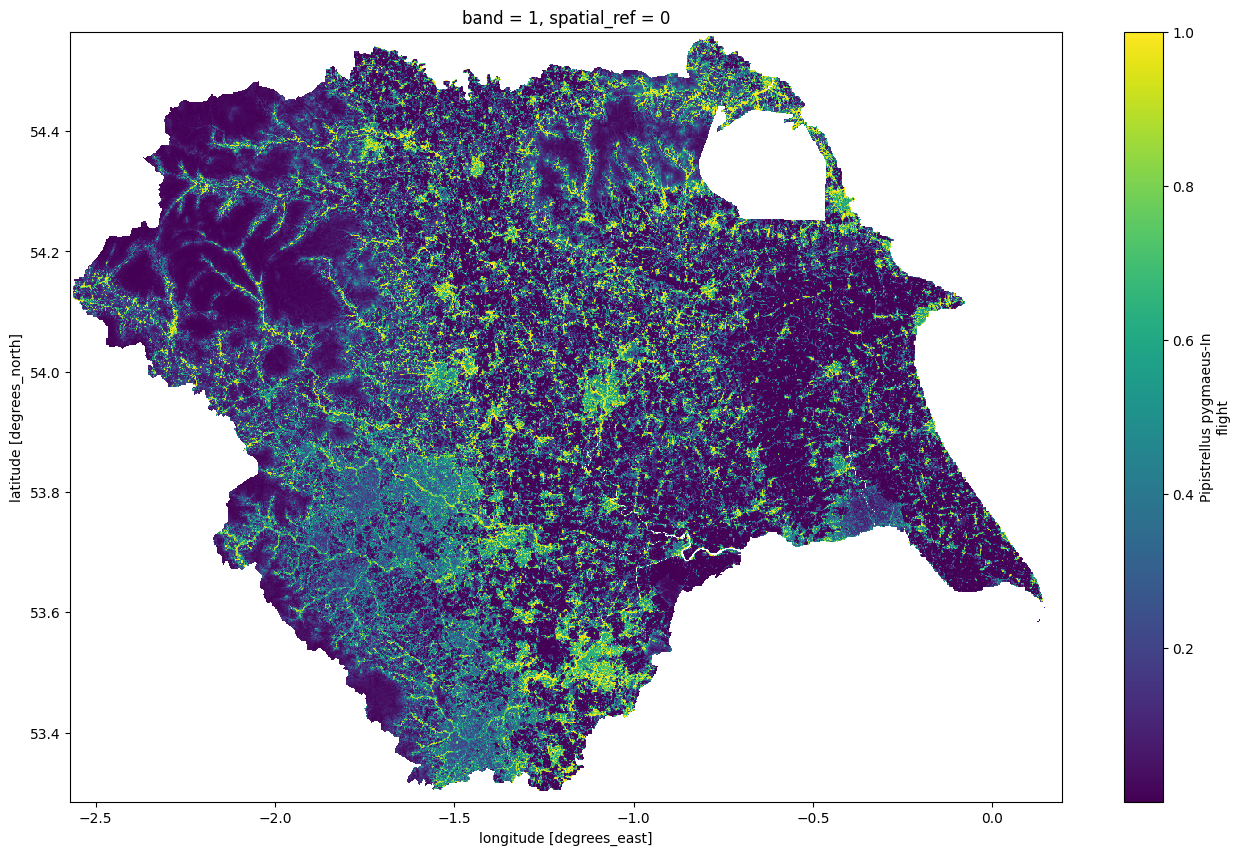

In [46]:
predictions.where(predictions > 0.0).plot(figsize=(16, 10))

In [35]:
import leafmap

m = leafmap.Map()
m.zoom_to_gdf(boundary_4326)
m.add_basemap("HYBRID")
m.add_raster(
    str(predictions_masked),
    layer_name="Predictions",
    cmap="viridis",
    nodata=np.nan,
    opacity=0.5,
)
m.add_gdf(
    species_presence,
    layer_name="Presence",
    point_style={"color": "orange", "weight": 1, "opacity": 0.7, "radius": 3},
)
m

Map(center=[53.925256000000005, -1.1879715000000002], controls=(ZoomControl(options=['position', 'zoom_in_text…

In [28]:
import numpy as np
import shap
import pandas as pd
from typing import Tuple, Optional


def compute_shap_for_pipeline(
    model,
    X: pd.DataFrame,
    feature_names,
    positive_class: int = 1,
    sample_size: int = 200,
    n_explain: Optional[int] = 200,
    random_state: int = 42,
) -> Tuple[shap.Explainer, shap._explanation.Explanation, pd.DataFrame]:
    """
    Compute SHAP values for a scikit-learn pipeline that supports predict_proba.

    Parameters
    ----------
    model
        Fitted sklearn Pipeline (or any estimator) with predict_proba.
    X
        DataFrame of input features (same structure as used for training).
    feature_names
        Sequence of feature names (columns of X, or subset/order used for model).
    positive_class
        Index of the positive class in predict_proba output.
    sample_size
        Number of background samples for the explainer.
    n_explain
        Number of rows to explain. If None, use all rows of X.
    random_state
        Seed for sampling.

    Returns
    -------
    explainer
        SHAP explainer object (can be reused).
    shap_values
        SHAP Explanation object for X_explain.
    X_explain
        DataFrame of rows that shap_values correspond to.
    """

    # Ensure we only use the requested features, in a consistent order
    X = X[list(feature_names)]

    # Background sample
    sample_size = min(sample_size, len(X))
    background = X.sample(n=sample_size, random_state=random_state)

    # Prediction function returning probability for positive class
    def predict_fn(data):
        proba = model.predict_proba(data)
        return proba[:, positive_class]

    explainer = shap.Explainer(
        predict_fn,
        background,
        algorithm="permutation",
        model_output="probability",
    )

    # Data to explain
    if n_explain is None:
        X_explain = X
    else:
        n_explain = min(n_explain, len(X))
        X_explain = X.sample(n=n_explain, random_state=random_state + 1)

    shap_values = explainer(X_explain)

    return explainer, shap_values, X_explain


explainer, shap_values, X_explain = compute_shap_for_pipeline(
    final_model,
    ev_gdf[feature_config],
    feature_names=feature_config,
    sample_size=100,
)


PermutationExplainer explainer: 201it [00:53,  3.12it/s]                         


In [29]:
print(latin_name)
print(activity_type)

Pipistrellus pygmaeus
In flight


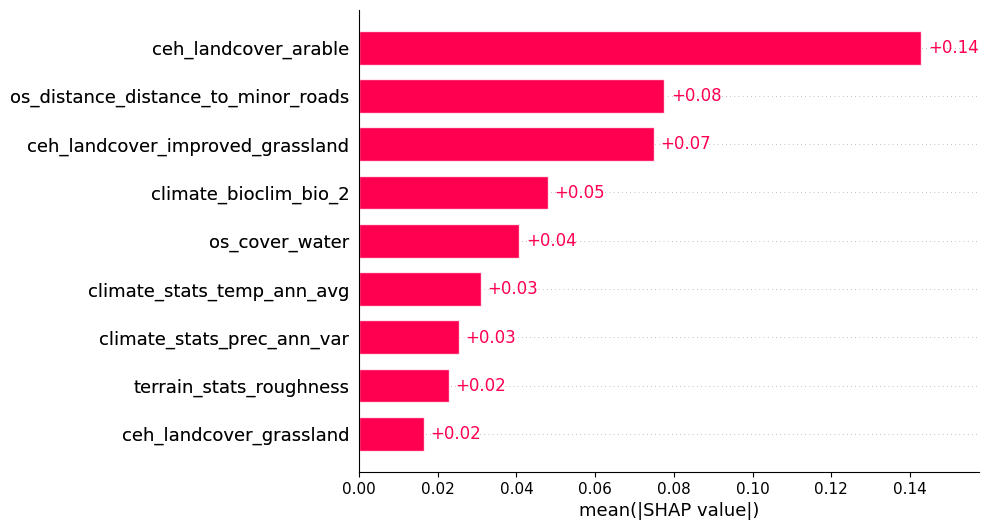

In [30]:
import numpy as np
import shap

# shap_values from your explainer call (for the positive class)
values = shap_values.values  # (n_samples, n_features)

# Global importance
shap.plots.bar(shap_values, max_display=25)  # new API


In [31]:
# order feature names by descending shap values
variable_contributions = pd.DataFrame(
    abs(shap_values.values.mean(axis=0)), index=feature_config, columns=["shap_mean"]
).sort_values(by="shap_mean", ascending=False)

variable_contributions

,shap_mean
ceh_landcover_arable,0.066738
climate_stats_temp_ann_avg,0.013869
climate_bioclim_bio_2,0.013287
ceh_landcover_improved_grassland,0.002100
climate_stats_prec_ann_var,0.001455
os_distance_distance_to_minor_roads,0.001206
os_cover_water,0.001066
ceh_landcover_grassland,0.000593
terrain_stats_roughness,0.000245


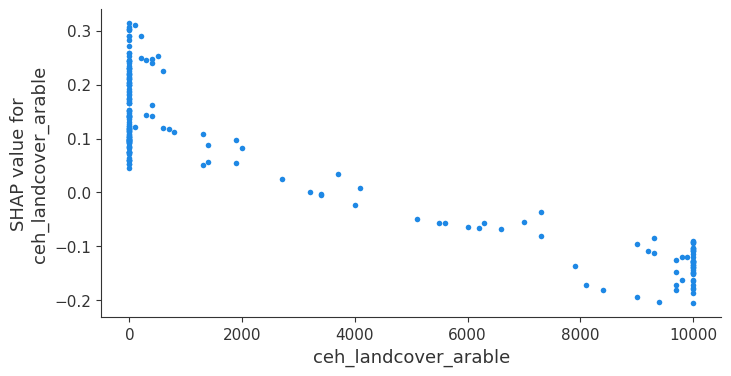

In [32]:
import numpy as np
import shap
import matplotlib.pyplot as plt


def plot_filtered_shap_dependence(
    feature_name,
    X_df,
    shap_values,
    p_low=1,
    p_high=99,
    interaction_index=None,
    fig=None,
    ax=None,
    figsize=(6, 4),
):
    """
    SHAP dependence plot filtered to percentile range, with support for
    passing in existing fig/ax so multiple plots can be placed in a panel.

    Parameters
    ----------
    feature_name : str
        Feature to plot.
    X_df : pandas.DataFrame
        Input features for the SHAP values.
    shap_values : shap.Explanation
        SHAP values aligned with X_df.
    p_low, p_high : int|float
        Percentile bounds for trimming the feature range.
    interaction_index : str|int|None
        Feature used for colour (None = same feature).
    fig, ax : matplotlib Figure/Axes or None
        If provided, SHAP will draw into this axis.
    figsize : tuple
        Only used if fig/ax are not provided.

    Returns
    -------
    fig, ax : Figure and Axes
    """

    # Compute percentile bounds
    low, high = np.percentile(X_df[feature_name], [p_low, p_high])

    # Filter rows to percentile limits
    mask = (X_df[feature_name] >= low) & (X_df[feature_name] <= high)
    X_filtered = X_df.loc[mask]
    shap_filtered = shap_values.values[mask, :]

    # Create fig/ax only if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        # If ax provided but fig not, use ax.figure
        if fig is None:
            fig = ax.figure

    # Draw SHAP plot on this axis
    shap.dependence_plot(
        feature_name,
        shap_filtered,
        X_filtered,
        interaction_index=interaction_index,
        ax=ax,
        show=False,
    )

    return fig, ax


fig, ax = plt.subplots(figsize=(8, 4))

fig, ax = plot_filtered_shap_dependence(
    variable_contributions.index[0],
    X_explain,
    shap_values,
    p_low=5,
    p_high=95,
    fig=fig,
    ax=ax,
)

fig.show()


In [33]:
# explain a single point

x, y = 401195, 475151

point_evs = evs_to_model.sel(x=[x], y=[y], method="nearest").to_dataframe()

point_features = point_evs[feature_config]

point_shap_values = explainer.shap_values(point_features)
point_shap_df = pd.DataFrame(
    data={
        "variable": feature_config,
        "input_value": point_features.values[0],
        "shap_score": point_shap_values[0],
    }
).sort_values(by="shap_score", ascending=False)


point_shap_df


,variable,input_value,shap_score
6,ceh_landcover_arable,0.000000,0.097526
7,os_cover_water,4.000000,0.019790
5,ceh_landcover_grassland,0.000000,0.004005
4,terrain_stats_roughness,0.006644,-0.008433
8,ceh_landcover_improved_grassland,0.000000,-0.021110
2,climate_stats_temp_ann_avg,6.674460,-0.030934
1,climate_stats_prec_ann_var,32.830372,-0.044278
3,os_distance_distance_to_minor_roads,2332.251953,-0.082065
0,climate_bioclim_bio_2,6.332520,-0.087849
